# Stage 2: first model

**Goal:** predict tomorrow's average PM2.5 for Delhi, Mumbai and Bengaluru, and find out whether a model beats two simple guesses.

**MLOps idea: baselines and evaluation.** A model's error means nothing on its own. "Off by 25 µg/m³" is good if the naive guess is off by 40, and bad if it's off by 20. So before training anything, we decide:
1. **What we measure:** mean absolute error (MAE), the average size of the miss in µg/m³. Also how often we get the AQI category right.
2. **What we compare against (baselines):**
   - *Persistence:* "tomorrow will be like today".
   - *CAMS:* the free forecast from a big physics model.
3. **How we test fairly:** train on older days and test on later days the model has never seen, exactly as it would be used in real life.

Run it top to bottom after `uv run python -m aqi_forecast.ingest --days 1500`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.precision", 1)
RAW = "../data/raw/"

## 1. Look at the raw station data

Each row is one station's average for one day. Before using it, we check how many stations report over time, and whether any values are impossible.

In [2]:
stations = pd.read_csv(RAW + "pm25_stations.csv", parse_dates=["date"])
print(f"{len(stations):,} rows from {stations.sensor_id.nunique()} sensors")
stations.pm25.describe()

59,489 rows from 180 sensors


count     59453.0
mean         73.5
std         987.9
min       -4210.0
25%          22.4
50%          40.1
75%          69.1
max      104000.0
Name: pm25, dtype: float64

PM2.5 can't be negative, and daily averages above about 1,000 µg/m³ don't happen even in Delhi's worst smog. The extreme values (some above 100,000) are sensor faults, so we drop them.

We also drop days where a station was running for less than 75% of the day (`coverage_pct`), because a 3-hour "daily average" isn't reliable.

Kept 51,214 of 59,489 rows (86%)


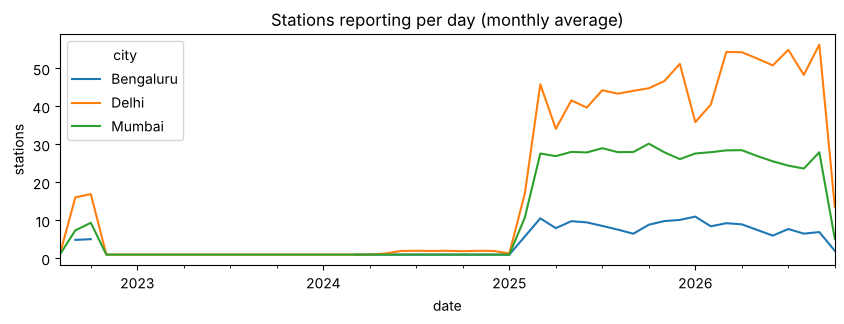

In [3]:
valid = stations[
    stations.pm25.between(1, 1000)
    & (stations.coverage_pct >= 75)
]
print(f"Kept {len(valid):,} of {len(stations):,} rows ({len(valid)/len(stations):.0%})")

reporting = valid.groupby(["date", "city"]).sensor_id.nunique().unstack()
reporting.resample("MS").mean().plot(figsize=(10, 3), title="Stations reporting per day (monthly average)")
plt.ylabel("stations");

**Surprise:** from early 2023 to the end of 2024, OpenAQ has just one or two stations per city. The data that's left isn't wrong, but OpenAQ has very little for those years.

A city average from one station is unreliable, so we only count a day when **at least 3 stations** reported. That leaves a few weeks in late 2022, plus February 2025 to now. It's less history than we hoped for, but it's honest. Filling the 2023 to 2024 gap from another source is a possible later improvement.

## 2. One number per city per day

We take the **median** of all stations. The median isn't thrown off by one faulty station, unlike the mean.

In [4]:
MIN_STATIONS = 3
city_daily = (
    valid.groupby(["city", "date"]).pm25.agg(pm25="median", n_stations="size").reset_index()
)
city_daily = city_daily[city_daily.n_stations >= MIN_STATIONS]
city_daily.groupby("city").agg(days=("pm25", "size"), first=("date", "min"), last=("date", "max"), median_pm25=("pm25", "median"))

,days,first,last,median_pm25
city,,,,
Bengaluru,580,2022-09-14,2026-10-01,24.4
Delhi,619,2022-09-14,2026-10-06,54.3
Mumbai,583,2022-09-14,2026-10-01,20.4


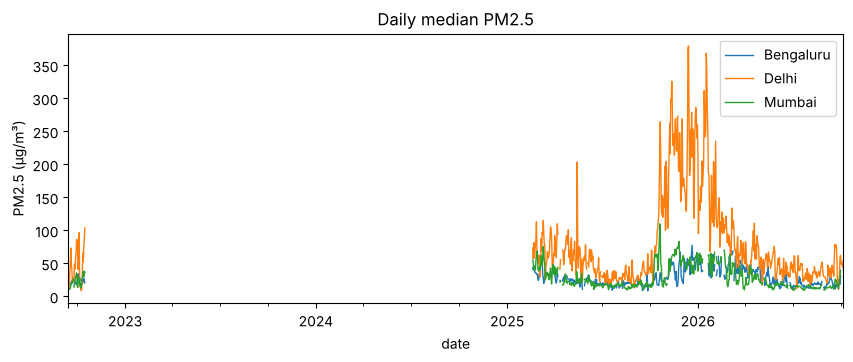

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.5))
for city, g in city_daily.groupby("city"):
    g.set_index("date").pm25.asfreq("D").plot(ax=ax, label=city, lw=1)
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Daily median PM2.5")
ax.legend();

Delhi's winter peaks (November to January) are the hardest days to predict and matter most for health. Mumbai and Bengaluru are much cleaner, and the monsoon months (June to September) are the cleanest everywhere.

## 3. Build features

A **feature** is anything the model can look at when making a prediction. The key rule is that we may only use information we'd actually **have** on the evening before. Using tomorrow's real PM2.5 as an input would be cheating. This mistake is called *data leakage*, and it's the most common way models look great in testing and fail in real use.

To predict day *t+1*, we use:
- PM2.5 today, yesterday, and the average of the last 7 days
- today's weather: temperature, humidity, rain, wind
- the CAMS forecast for tomorrow, which is published in advance, so using it is fair
- the time of year and day of the week

In [6]:
weather = pd.read_csv(RAW + "weather.csv", parse_dates=["date"])
cams = pd.read_csv(RAW + "cams_pm25.csv", parse_dates=["date"])

def make_features(city_daily, weather, cams):
    frames = []
    for city, g in city_daily.groupby("city"):
        # one row per calendar day, so shift(1) always means "the previous day"
        days = pd.date_range(g.date.min(), g.date.max(), name="date")
        d = g.set_index("date").reindex(days)[["pm25"]]
        d["city"] = city
        d["pm25_lag1"] = d.pm25.shift(1)
        d["pm25_7d_mean"] = d.pm25.rolling(7, min_periods=4).mean()
        d["target"] = d.pm25.shift(-1)  # tomorrow: what we want to predict
        frames.append(d.reset_index())
    df = pd.concat(frames)

    df = df.merge(weather, on=["city", "date"], how="left")
    rad = np.deg2rad(df.pop("wind_direction_10m_dominant"))
    df["wind_dir_sin"], df["wind_dir_cos"] = np.sin(rad), np.cos(rad)

    tomorrow_cams = cams.assign(date=cams.date - pd.Timedelta(days=1))
    df = df.merge(tomorrow_cams.rename(columns={"cams_pm25": "cams_tomorrow"}), on=["city", "date"], how="left")

    tomorrow = df.date + pd.Timedelta(days=1)
    df["doy_sin"] = np.sin(2 * np.pi * tomorrow.dt.dayofyear / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * tomorrow.dt.dayofyear / 365.25)
    df["dow"] = tomorrow.dt.dayofweek
    df["city"] = df.city.astype("category")
    return df.dropna(subset=["pm25", "target"])

df = make_features(city_daily, weather, cams)
FEATURES = [c for c in df.columns if c not in ("date", "target")]
print(f"{len(df):,} rows, {len(FEATURES)} features: {FEATURES}")

1,731 rows, 14 features: ['pm25', 'city', 'pm25_lag1', 'pm25_7d_mean', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'wind_dir_sin', 'wind_dir_cos', 'cams_tomorrow', 'doy_sin', 'doy_cos', 'dow']


## 4. Split by time

We train on everything up to the end of 2025 and test on 2026. We never shuffle randomly: a random split lets the model peek at days on both sides of a test day, which makes the scores look better than they really are.

In [7]:
SPLIT = "2026-01-01"
train, test = df[df.date < SPLIT], df[df.date >= SPLIT]
print(f"train: {len(train):,} rows ({train.date.min():%b %Y} to {train.date.max():%b %Y})")
print(f"test:  {len(test):,} rows ({test.date.min():%b %Y} to {test.date.max():%b %Y})")

train: 978 rows (Sep 2022 to Dec 2025)
test:  753 rows (Jan 2026 to Oct 2026)


## 5. Train models

### Try 1: LightGBM, predicting PM2.5 directly

**LightGBM** builds hundreds of small decision trees, each one correcting the mistakes of the previous ones. It's a strong default for tables of numbers, and it copes with missing values on its own.

In [8]:
LGB_PARAMS = dict(
    n_estimators=400, learning_rate=0.03, num_leaves=15, min_child_samples=20,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=42, verbose=-1,
)
lgb_direct = lgb.LGBMRegressor(**LGB_PARAMS).fit(train[FEATURES], train.target)
preds = pd.DataFrame({
    "persistence": test.pm25,
    "cams": test.cams_tomorrow,
    "lgb_direct": lgb_direct.predict(test[FEATURES]),
}, index=test.index)

mae = lambda col: mean_absolute_error(test.target, preds[col])
print({col: round(mae(col), 1) for col in preds})

{'persistence': 8.4, 'cams': 18.8, 'lgb_direct': 9.7}


**The first model lost to "tomorrow equals today".** This happens a lot in real projects, and it's exactly why we set baselines first. Without one, we'd have shipped this and felt good about it.

Why it lost:
- Decision trees can only predict values similar to ones they saw in training. When Delhi has an unusually bad day, the trees can't go higher than their training range.
- We have under 1,000 training rows. That's small for a model with this many settings.

### Try 2: predict the *change*, not the level

Instead of "what will PM2.5 be tomorrow?", we ask "by what factor will it change?" We do this with logs: `log(tomorrow) − log(today)`. A day at 300 that becomes 330 and a day at 30 that becomes 33 are now the same pattern (+10%), so the model learns from both cities at once.

In [9]:
log_change = np.log(train.target) - np.log(train.pm25)
lgb_change = lgb.LGBMRegressor(**LGB_PARAMS).fit(train[FEATURES], log_change)
preds["lgb_change"] = test.pm25 * np.exp(lgb_change.predict(test[FEATURES]))
print({col: round(mae(col), 1) for col in preds})

{'persistence': 8.4, 'cams': 18.8, 'lgb_direct': 9.7, 'lgb_change': 7.4}


### Try 3: a simple linear model on the same idea

With little data, a simpler model is often better. **Ridge regression** fits one straight-line weight per feature, and it's built so that no single weight can grow huge. For it, we put the PM2.5 columns on a log scale and fill a missing lag with today's value.

In [10]:
LOG_COLS = ["pm25", "pm25_lag1", "pm25_7d_mean", "cams_tomorrow"]

def ridge_inputs(d):
    x = d[FEATURES].copy()
    for col in LOG_COLS:
        x[col] = np.log(x[col].fillna(d.pm25))
    x = pd.get_dummies(x, columns=["city", "dow"], dtype=float)
    return x.fillna(0)

ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 20)))
ridge.fit(ridge_inputs(train), np.log(train.target))
preds["ridge"] = np.exp(ridge.predict(ridge_inputs(test)))
print({col: round(mae(col), 1) for col in preds})

{'persistence': 8.4, 'cams': 18.8, 'lgb_direct': 9.7, 'lgb_change': 7.4, 'ridge': 7.1}


## 6. Compare everything

Besides MAE, we check **category accuracy**: how often the forecast lands in the same band of India's AQI scale as what actually happened. For PM2.5 the bands are Good up to 30, Satisfactory up to 60, Moderate up to 90, Poor up to 120, Very Poor up to 250, and Severe above that. The category is what a person actually acts on.

In [11]:
BANDS = [0, 30, 60, 90, 120, 250, np.inf]
LABELS = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
band = lambda x: pd.cut(x, BANDS, labels=LABELS)

def scores(rows):
    t, p = test.loc[rows], preds.loc[rows]
    return pd.DataFrame({
        col: {"MAE (µg/m³)": mean_absolute_error(t.target, p[col]),
              "category right (%)": (band(t.target) == band(p[col])).mean() * 100}
        for col in preds
    }).T

groups = {"All cities": test.index, **{c: g.index for c, g in test.groupby("city", observed=True)}}
results = pd.concat({name: scores(rows) for name, rows in groups.items()}, axis=1)
results.round(1)

All cities                      Bengaluru                     \
            MAE (µg/m³) category right (%) MAE (µg/m³) category right (%)   
persistence         8.4               80.1         4.6               86.1   
cams               18.8               61.5        10.3               73.8   
lgb_direct          9.7               77.8         4.6               87.3   
lgb_change          7.4               79.9         4.5               86.1   
ridge               7.1               81.0         4.1               87.3   

                  Delhi                         Mumbai                     
            MAE (µg/m³) category right (%) MAE (µg/m³) category right (%)  
persistence        15.5               67.3         4.0               89.1  
cams               37.5               31.7         5.6               84.0  
lgb_direct         19.0               60.1         4.0               89.1  
lgb_change         13.1               66.9         3.8               89.1  
ridge              12.9               68.3         3.3               89.5

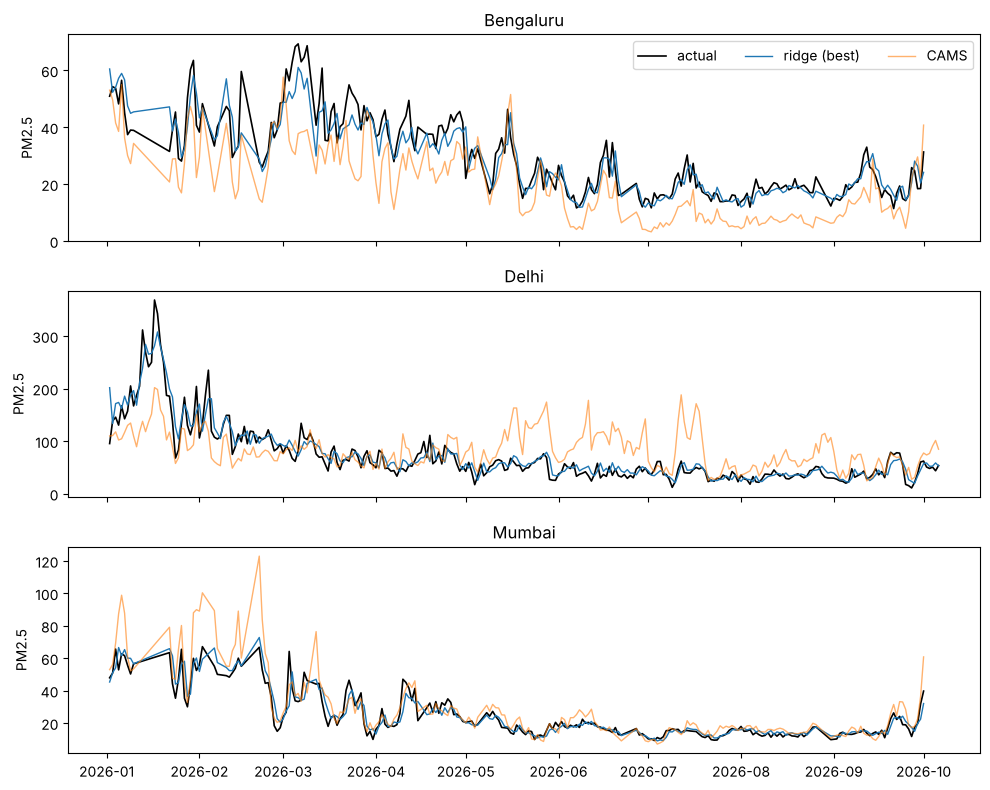

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, (city, g) in zip(axes, test.groupby("city", observed=True)):
    day = g.date + pd.Timedelta(days=1)
    ax.plot(day, g.target, color="black", lw=1.2, label="actual")
    ax.plot(day, preds.loc[g.index, "ridge"], lw=1, label="ridge (best)")
    ax.plot(day, preds.loc[g.index, "cams"], lw=1, alpha=0.6, label="CAMS")
    ax.set_title(city); ax.set_ylabel("PM2.5")
axes[0].legend(ncol=3)
plt.tight_layout();

## 7. What did the model rely on?

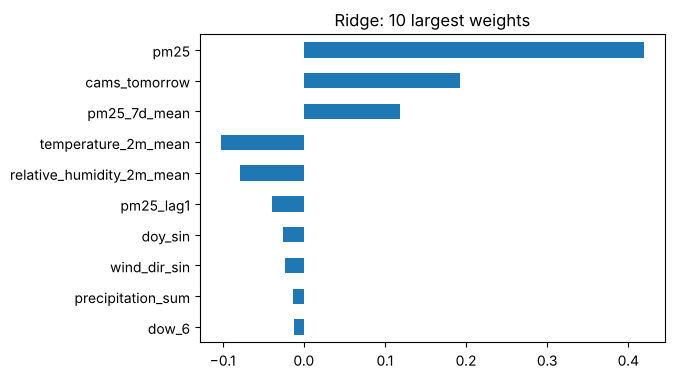

In [13]:
weights = pd.Series(ridge[-1].coef_, index=ridge_inputs(train).columns)
weights[weights.abs().sort_values().index[-10:]].plot.barh(figsize=(6, 4), title="Ridge: 10 largest weights");

Bars to the right push tomorrow's forecast up, and bars to the left push it down. Today's PM2.5 and the CAMS forecast for tomorrow should carry most of the weight.

## What we learned

- **Data is the hard part.** We dropped broken sensor values, partial days and a two-year gap before training anything.
- **Baselines keep us honest.** The first LightGBM model was *worse* than "tomorrow equals today" (MAE 9.7 vs 8.4). Without a baseline, we'd never have noticed.
- **How you frame the problem matters more than which algorithm you pick.** Predicting the change on a log scale took LightGBM from 9.7 to 7.4. A simple ridge model on the same idea did best, at **7.1 µg/m³, about 15% better than persistence**, with the biggest gain in Delhi (12.9 vs 15.5).
- **CAMS alone is a poor forecast at street level.** It overestimates Delhi in the monsoon and underestimates Bengaluru. As one input among several, though, it is the model's second-most useful clue.

**Weak spots to keep in mind:**
- The test period has only one winter peak (January), so Delhi's November smog isn't tested yet.
- Training covers only about 11 months of good data.
- Forecasts trail sudden jumps by a day, as the chart shows. That's typical for models that lean on today's value.

**Next (stage 3):** this notebook works, but you have to run it by hand and nothing checks it. We'll move the logic into scripts (`features.py`, `train.py`) with tests, including a check that would have caught the 100,000 µg/m³ readings automatically.